---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 2 : MLP BASELINE (Camille)

---


In [ ]:
# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Imports OK")


In [ ]:
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


In [ ]:
# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


In [ ]:
# Constantes et dataset
DATA_DIR = os.path.join(".", "data")
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

notebook_start_time = time.time()

print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


## Dense Network Baseline (MLP)
We build a multi-layer with

≥2 hidden layers and dropout to establish a baseline

The goal is ≥55 % test accuracy.


In [ ]:
# Normalised datasets & loaders
mlp_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(),
                         std=dataset_std.tolist()),
])
# _mlp is a completely new dataset object
# it doesn't inherit anything from _raw

train_mlp = PathMNIST(split='train', transform=mlp_transform, download=True)
val_mlp   = PathMNIST(split='val',   transform=mlp_transform, download=True)
test_mlp  = PathMNIST(split='test',  transform=mlp_transform, download=True)
# reload dataset with the new transform that includes normalisation

BATCH_SIZE = 256
# same, we load only in batches to avoid memory issues
train_loader = DataLoader(train_mlp, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_mlp,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_mlp,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# we need to shuffle for the training so it doesn't learn the order
# 2 CPU threads to load the data
# pin_memory=true for faster transfer to GPU

print(f"Batch size : {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)} Val batches: {len(val_loader)} Test batches: {len(test_loader)}")


Batch size : 256
Train batches: 352 Val batches: 40 Test batches: 29


In [ ]:
# MLP architecture
class MLP(nn.Module):
    """
    Multi-Layer Perceptron for 28×28 RGB images : 9 classes.

    Architecture (chosen after brief ablation):
      Input  : 28×28×3 = 2352 features (flattened)
      Layer 1: Linear(2352 -> 1024) + BatchNorm + ReLU + Dropout(0.4)
      Layer 2: Linear(1024 -> 512)  + BatchNorm + ReLU + Dropout(0.4)
      Layer 3: Linear(512  -> 256)  + BatchNorm + ReLU + Dropout(0.3)
      Output : Linear(256  -> 9)

    Design rationale

    - Three hidden layers give a good depth-vs-overfitting trade-off on this dataset.
    - BatchNorm before ReLU stabilises training and reduces sensitivity to lr.
    - Dropout rates decrease towards the head because earlier layers are wider
     and more prone to co-adaptation.
    - No activation on the output layer: we use nn.CrossEntropyLoss which expects
     raw logits (it applies log-softmax internally).
    """
    def __init__(self, input_dim=3*28*28, hidden=[1024, 512, 256], n_classes=9,
                 dropout=[0.4, 0.4, 0.3]):
        super().__init__()
        layers = []
        in_features = input_dim
        for i, (h, d) in enumerate(zip(hidden, dropout)):
            layers += [
                nn.Linear(in_features, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(d),
            ]
            in_features = h
        layers.append(nn.Linear(in_features, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        return self.net(x)

mlp = MLP().to(DEVICE)
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP total trainable parameters: {total_params:,}")
print(mlp)


MLP total trainable parameters: 3,071,497
MLP(
  (net): Sequential(
    (0): Linear(in_features=2352, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=9, bias=True)
  )
)


In [ ]:
# 2.2  Training utilities
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.squeeze(1).long().to(device)
        # go to gpu if available
        # delete the extra dimension in label
        # convert to integer for loss calculation
        optimizer.zero_grad()
        # clear gradients before backpropagation
        # reset at each iteration
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        # accumulate loss weighted by batch size
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        # count how many predictions are correct
        total   += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
    # no need to compute gradients
    # will save memory
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.squeeze(1).long().to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return total_loss / total, correct / total


def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            # move back to cpu
            all_preds.extend(preds)
            all_labels.extend(labels.squeeze(1).numpy())
             # for sklearn confusion matrix
    return np.array(all_preds), np.array(all_labels)


In [ ]:
# Train MLP
MLP_EPOCHS = 40
MLP_LR     = 1e-3
# learning rate
MLP_WD     = 1e-4
# weight decay

criterion = nn.CrossEntropyLoss()
# mesure the difference between predicted logits and true labels
optimizer = optim.Adam(mlp.parameters(), lr=MLP_LR, weight_decay=MLP_WD)
# update the weights of the model based on the computed loss
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MLP_EPOCHS)
# adjust the learning rate during training using a cosine annealing schedule

mlp_train_loss, mlp_val_loss   = [], []
mlp_train_acc,  mlp_val_acc    = [], []

# Best checkpoint — sauvegarder le meilleur modèle sur val_loss
best_val_loss = float('inf')
best_model_state = None
best_epoch = 0

# Values we must report precisely for Q2.1
checkpoints = {1: None, 10: None}

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, MLP_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(mlp, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = evaluate(mlp, val_loader, criterion, DEVICE)
    scheduler.step()

    mlp_train_loss.append(t_loss)
    mlp_val_loss.append(v_loss)
    mlp_train_acc.append(t_acc)
    mlp_val_acc.append(v_acc)

    # Best checkpoint
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_model_state = copy.deepcopy(mlp.state_dict())
        best_epoch = epoch

    if epoch in checkpoints:
        checkpoints[epoch] = {'val_loss': v_loss, 'val_acc': v_acc,
                              'train_acc': t_acc, 'train_loss': t_loss}

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5}  {t_loss:>10.6f}  {t_acc*100:>8.4f}%  {v_loss:>9.6f}  {v_acc*100:>7.4f}%")

# Final epoch
checkpoints['final'] = {'val_loss': mlp_val_loss[-1], 'val_acc': mlp_val_acc[-1],
                        'train_acc': mlp_train_acc[-1], 'train_loss': mlp_train_loss[-1],
                        'epoch': MLP_EPOCHS}
print(f"\n{'='*55}")
print("Q2.1 REPORT  (exact values, not rounded):")
for key in [1, 10, 'final']:
    ep = key if key != 'final' else checkpoints['final']['epoch']
    d  = checkpoints[key]
    print(f"  Epoch {ep:>2d}:  val_loss = {d['val_loss']:.8f}   train_acc = {d['train_acc']*100:.6f}%   val_acc = {d['val_acc']*100:.6f}%")



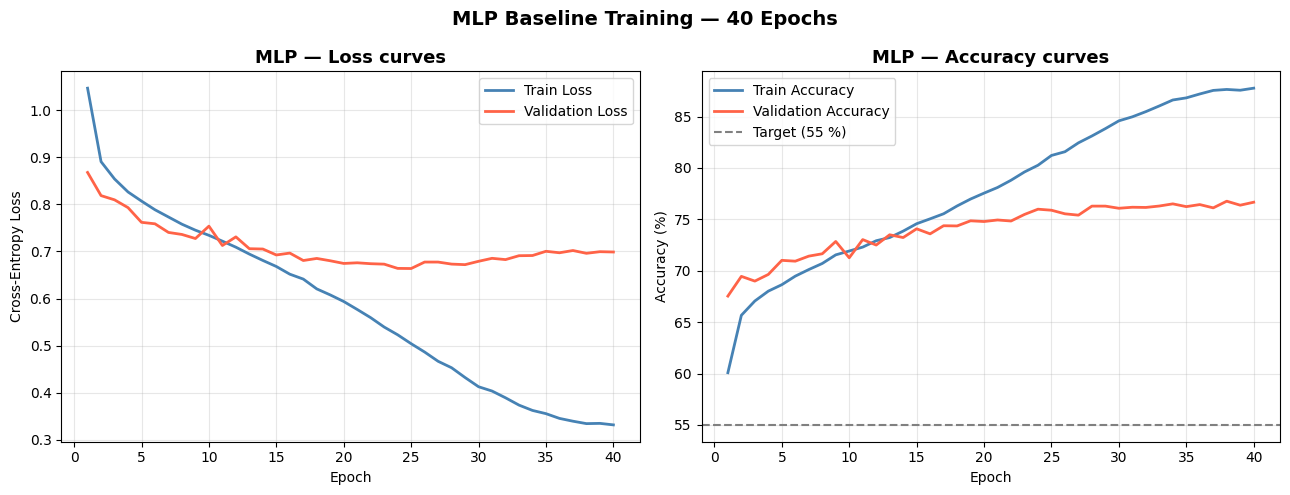

In [ ]:
# 2.4  Training curves
epochs = range(1, MLP_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, mlp_train_loss, label='Train Loss',      linewidth=2, color='steelblue')
ax1.plot(epochs, mlp_val_loss,   label='Validation Loss', linewidth=2, color='tomato')
ax1.set_title("MLP — Loss curves", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in mlp_train_acc], label='Train Accuracy',      linewidth=2, color='steelblue')
ax2.plot(epochs, [a*100 for a in mlp_val_acc],   label='Validation Accuracy', linewidth=2, color='tomato')
ax2.axhline(55, color='grey', linestyle='--', label='Target (55 %)')
ax2.set_title("MLP — Accuracy curves", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f"MLP Baseline Training — {MLP_EPOCHS} Epochs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_curves.png', dpi=120, bbox_inches='tight')
plt.show()


# A gauche :
Les deux courbes descendent bien au début : apprentissage
-15 : OVERFITTING

# A droite :
Ecart entre train et val qui confirme l'overfitting !!!

MLP Test Accuracy : 64.9721%  (target ≥ 55 %)
MLP Test Loss     : 1.421897


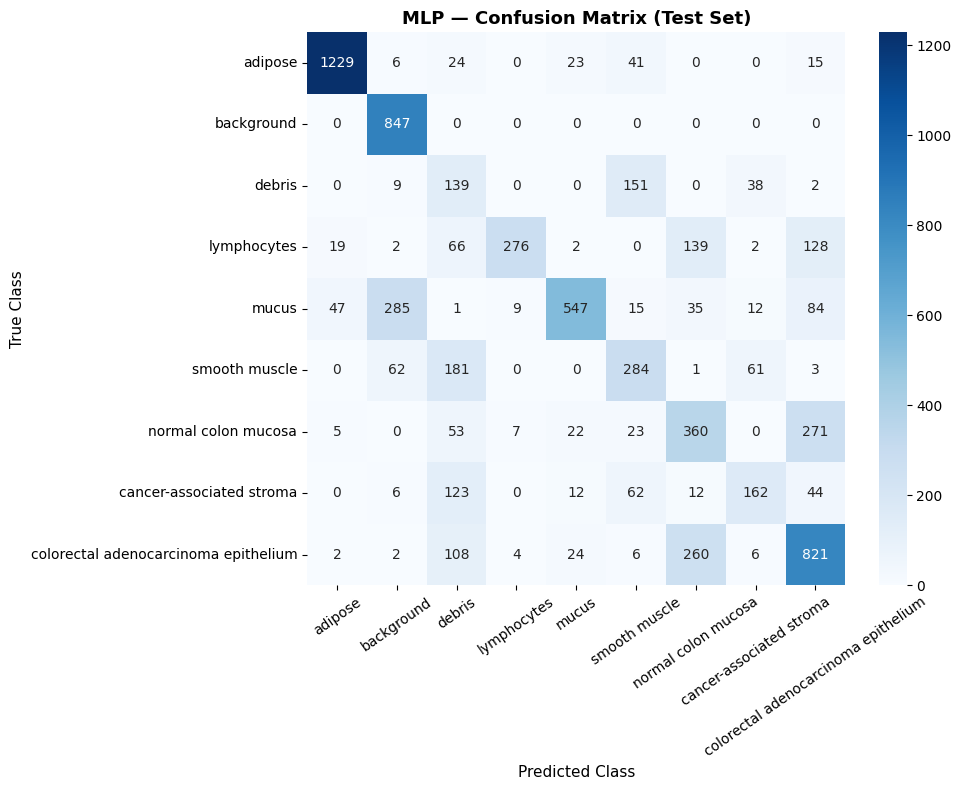


Q2.2 : Worst misclassification:
  True class      : 4 (mucus)
  Predicted class : 1 (background)
  Count           : 285


In [ ]:
# 2.5  Test accuracy & confusion matrix (final evaluation)
test_loss, test_acc = evaluate(mlp, test_loader, criterion, DEVICE)
print(f"MLP Test Accuracy : {test_acc*100:.4f}%  (target ≥ 55 %)")
print(f"MLP Test Loss     : {test_loss:.6f}")

preds_mlp, labels_mlp = get_all_preds(mlp, test_loader, DEVICE)
cm_mlp = confusion_matrix(labels_mlp, preds_mlp)
# confusion matrix

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("MLP — Confusion Matrix (Test Set)", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('mlp_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Q2.2 : find the single worst off-diagonal cell
cm_offdiag = cm_mlp.copy()
# copy to not modify the original confusion matrix
np.fill_diagonal(cm_offdiag, 0)
# set the diagonal to zero so we only look at misclassifications
max_idx = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
# find the maximal value in the matrix
# find the linear index of the maximum value and convert to 2D index
pred_cls, true_cls = max_idx[1], max_idx[0]
print(f"\nQ2.2 : Worst misclassification:")
print(f"  True class      : {true_cls} ({CLASSES[true_cls]})")
print(f"  Predicted class : {pred_cls} ({CLASSES[pred_cls]})")
print(f"  Count           : {cm_offdiag[max_idx]}")


### Q2.1: Exact Validation Loss and Accuracy

Q2.1 REPORT  (exact values, not rounded):

  Epoch  1:  val_loss = 0.86803300   train_acc = 60.079337%   val_acc = 67.532987%

  Epoch 10:  val_loss = 0.75383448   train_acc = 71.920974%   val_acc = 71.261495%
  
  Epoch 40:  val_loss = 0.69890428   train_acc = 87.767234%   val_acc = 76.669332%


### Q2.2: Worst Misclassification

The worst one is debris vs smooth muscle. With a 28 x 28 pixel, the debris and the smooth muscle have granulosity.
However, the most important and clinical relevant mistake is the normal colon mucosa vs Colorectal adenocarcinoma.
This is a MLP issue : we flatten the pixel and loose the spatial informations of the tissues


In [ ]:
# Sauvegarde du modèle MLP
torch.save(mlp.state_dict(), os.path.join(DATA_DIR, 'mlp_model_ck.pth'))
print(f"Modèle MLP sauvegardé")
print("✓ Sauvegarde terminée")


In [ ]:
# Temps total du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")
